In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df=df[df['person_emp_length']<=60]

In [9]:
df['person_emp_length']=df['person_emp_length'].fillna(df['person_emp_length'].median())

/tmp/ipykernel_3628/715972081.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['person_emp_length']=df['person_emp_length'].fillna(df['person_emp_length'].median())


In [10]:
df['loan_int_rate']=df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_3628/2138848943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['loan_int_rate']=df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))


In [11]:
df.duplicated().sum()

np.int64(157)

In [12]:
df=df.drop_duplicates()

In [13]:
round(df['loan_status'].value_counts(normalize=True)*100,2)

,proportion
loan_status,
0,78.41
1,21.59


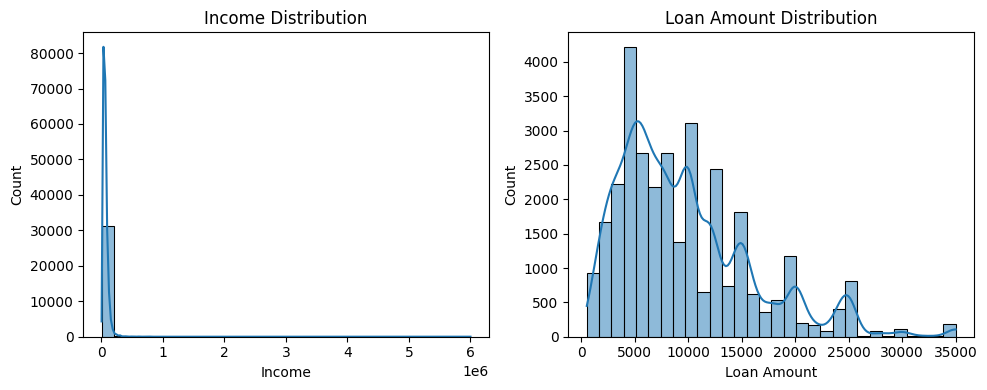

In [14]:
fig, axes = plt.subplots(1,2, figsize=(10, 4))

sns.histplot(df['person_income'], ax=axes[0], kde=True,bins=30)
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Income')

sns.histplot(df['loan_amnt'], ax=axes[1], kde=True,bins=30)
axes[1].set_title('Loan Amount Distribution')
axes[1].set_xlabel('Loan Amount')

plt.tight_layout()
plt.show()

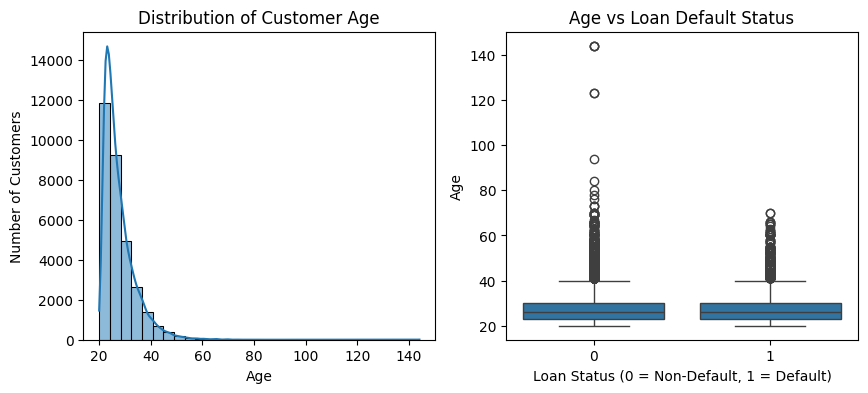

In [16]:
fig, axes = plt.subplots(1,2, figsize=(10, 4))
sns.histplot(df['person_age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Customer Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(x='loan_status', y='person_age', data=df, ax=axes[1])
axes[1].set_title('Age vs Loan Default Status')
axes[1].set_xlabel('Loan Status (0 = Non-Default, 1 = Default)')
axes[1].set_ylabel('Age')

plt.show()

In [17]:
df['person_income'].sort_values().head(10)

,person_income
31930,4000
15964,4080
15963,4200
15961,4800
15960,4800
15962,4800
32547,4888
15959,5000
16216,5000
15958,5500


In [18]:
df['person_income'].sort_values(ascending=False).head(10)

,person_income
32297,6000000
30049,2039784
32546,1900000
32497,1782000
31924,1440000
31922,1362000
17833,1200000
29120,1200000
29119,1200000
17834,948000


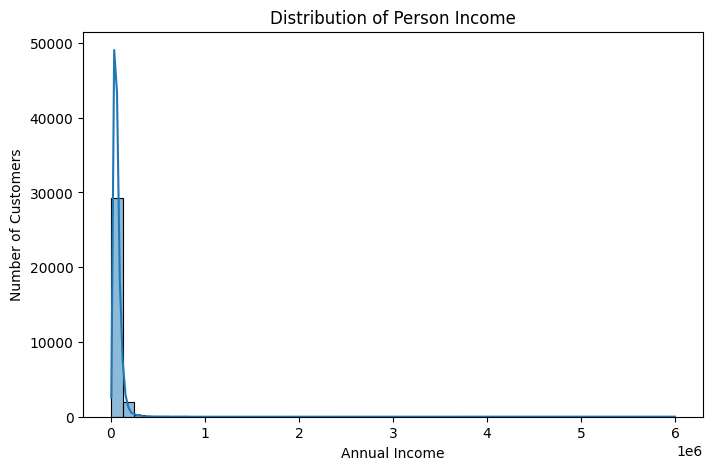

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['person_income'], bins=50, kde=True)

plt.title('Distribution of Person Income')
plt.xlabel('Annual Income')
plt.ylabel('Number of Customers')

plt.show()

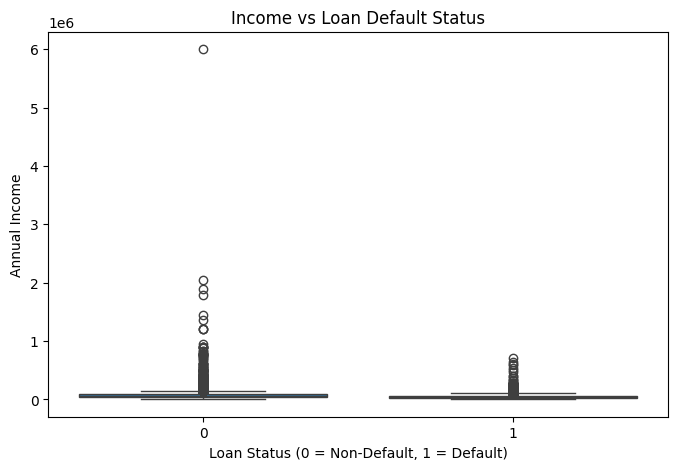

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='loan_status', y='person_income', data=df)

plt.title('Income vs Loan Default Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Annual Income')

plt.show()

In [23]:
df['loan_grade'].value_counts()

,count
loan_grade,
A,10300
B,10124
C,6303
D,3549
E,951
F,236
G,64


In [28]:
from sklearn.preprocessing import LabelEncoder

df[['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']] = df[['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']].apply(LabelEncoder().fit_transform)

In [31]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
df['Loan_Income_Ratio'] = df['loan_amnt'] / df['person_income']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
from sklearn.metrics import classification_report

pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4997
           1       0.96      0.71      0.82      1309

    accuracy                           0.93      6306
   macro avg       0.95      0.85      0.89      6306
weighted avg       0.94      0.93      0.93      6306



In [41]:
importance = rf.feature_importances_

pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

,Feature,Importance
8,loan_percent_income,0.225614
1,person_income,0.145824
5,loan_grade,0.118700
7,loan_int_rate,0.113115
2,person_home_ownership,0.093067
4,loan_intent,0.077221
6,loan_amnt,0.075174
3,person_emp_length,0.064752
0,person_age,0.043269
10,cb_person_cred_hist_length,0.034550
